In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


In [9]:
start = '1989-01-01'
end = '2023-12-31'

stock = 'MSFT'
data = yf.download(stock,start,end)

/var/folders/_k/41pjm0pd4051klhdyyg2vvzw0000gn/T/ipykernel_62946/3583337468.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock,start,end)
[*********************100%***********************]  1 of 1 completed


In [10]:
data.reset_index(inplace=True)

In [11]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,MSFT,MSFT,MSFT,MSFT,MSFT
0,1989-01-03,0.227480,0.228011,0.223768,0.226950,51825600
1,1989-01-04,0.230131,0.232783,0.226950,0.226950,53899200
2,1989-01-05,0.226420,0.232252,0.225890,0.232252,47246400
3,1989-01-06,0.224829,0.228011,0.224829,0.226950,59054400
4,1989-01-09,0.222708,0.225890,0.221117,0.224829,46008000
...,...,...,...,...,...,...
8812,2023-12-22,369.077087,369.668279,367.234564,368.190315,17107500
8813,2023-12-26,369.155945,371.402449,368.012983,369.490946,12673100
8814,2023-12-27,368.574585,369.550031,367.333086,368.200163,14905400


In [12]:
mva_days=data.Close.rolling(200).mean()
win_size=2
arr1=np.array(mva_days)
arr2=np.array(data.Close)
print(arr1)
print(arr2)

[[         nan]
 [         nan]
 [         nan]
 ...
 [323.05146202]
 [323.62360443]
 [324.17672729]]
[[2.27480382e-01]
 [2.30131432e-01]
 [2.26419955e-01]
 ...
 [3.68574585e+02]
 [3.69766846e+02]
 [3.70515686e+02]]


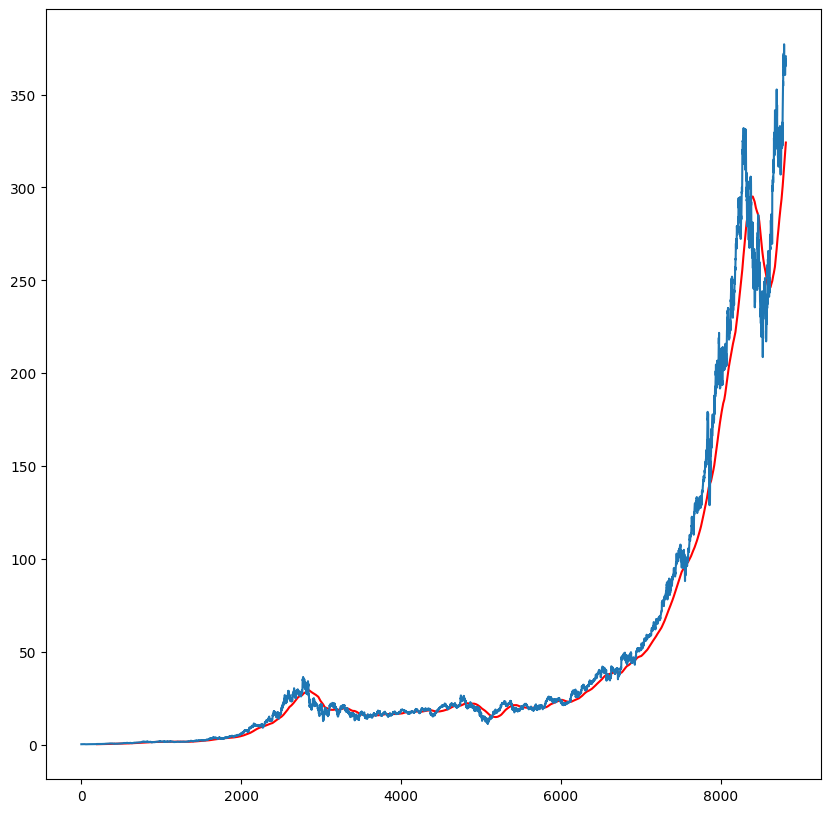

In [13]:
plt.figure(figsize=(10,10))
plt.plot(mva_days,'r')
plt.plot(data.Close)
plt.show()

In [14]:
def directional_change(close: np.array, high: np.array, low: np.array, sigma: float):
    
    up_zig = True # Last extreme is a bottom. Next is a top. 
    tmp_max = high[0]
    tmp_min = low[0]
    tmp_max_i = 0
    tmp_min_i = 0

    tops = []
    bottoms = []

    for i in range(len(close)):
        if up_zig: # Last extreme is a bottom
            if high[i] > tmp_max:
                # New high, update 
                tmp_max = high[i]
                tmp_max_i = i
            elif close[i] < tmp_max - tmp_max * sigma: 
                # Price retraced by sigma %. Top confirmed, record it
                # top[0] = confirmation index
                # top[1] = index of top
                # top[2] = price of top
                top = [i, tmp_max_i, tmp_max]
                tops.append(top)

                # Setup for next bottom
                up_zig = False
                tmp_min = low[i]
                tmp_min_i = i
        else: # Last extreme is a top
            if low[i] < tmp_min:
                # New low, update 
                tmp_min = low[i]
                tmp_min_i = i
            elif close[i] > tmp_min + tmp_min * sigma: 
                # Price retraced by sigma %. Bottom confirmed, record it
                # bottom[0] = confirmation index
                # bottom[1] = index of bottom
                # bottom[2] = price of bottom
                bottom = [i, tmp_min_i, tmp_min]
                bottoms.append(bottom)

                # Setup for next top
                up_zig = True
                tmp_max = high[i]
                tmp_max_i = i

    return tops, bottoms

tops1, bottoms1 = directional_change(
    arr1,
    data.High.values,
    data.Low.values,
    0.01
)


arr_tops1=[]
arr_bottoms1=[]
for i in range(len(tops1)):
    arr_tops1.append(tops1[i][2])

for i in range(len(bottoms1)):
    arr_bottoms1.append(bottoms1[i][2])
    
print(len(arr_tops1))
print(len(arr_bottoms1))
print((arr_tops1))
print((arr_bottoms1))

extremes=np.concatenate((arr_tops1,arr_bottoms1))


197
196
[array([0.3520905]), array([0.40299514]), array([0.63206615]), array([0.54086232]), array([0.50904635]), array([0.53661975]), array([0.58116178]), array([0.55783006]), array([0.59812983]), array([0.77205387]), array([0.87492432]), array([1.10081292]), array([1.46032788]), array([1.51441414]), array([1.48896159]), array([1.44601094]), array([1.47464458]), array([1.5653183]), array([1.54622937]), array([1.61304195]), array([1.57963579]), array([1.62258657]), array([1.80870662]), array([1.641675]), array([1.81825106]), array([1.63213084]), array([1.63690323]), array([1.62735882]), array([1.60349708]), array([1.65121993]), array([1.65121993]), array([1.58918059]), array([1.62735929]), array([2.01391666]), array([2.19526437]), array([2.49114776]), array([2.82520971]), array([4.17100217]), array([3.74626538]), array([3.41697446]), array([3.61741224]), array([3.48856017]), array([3.44083806]), array([3.56014504]), array([3.59832294]), array([3.97056446]), array([4.63391374]), array([5

In [15]:
data_train = pd.DataFrame(extremes[0: int(len(extremes)*0.80)])
data_test = pd.DataFrame(extremes[int(len(extremes)*0.80): len(extremes)])



In [16]:
data_train.shape[0]

314

In [17]:
data_test.shape[0]


79

In [18]:
from sklearn.preprocessing import MinMaxScaler as mms
scaler = mms(feature_range=(0,1))


In [19]:
data_train_scale=scaler.fit_transform(data_train)


In [20]:
x=[]
y=[]

for i in range (win_size,data_train_scale.shape[0]):
    x.append(data_train_scale[i-win_size:i])
    y.append(data_train_scale[i,0])
    

In [21]:
x, y = np.array(x), np.array(y)
x.shape[0]

312

In [22]:
import tensorflow.keras as keras
from keras.layers import Dense, Dropout,LSTM
from keras.models import Sequential

/Users/arpan25/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [23]:
model = Sequential()
model.add(LSTM(units = 50, return_sequences =True,
               input_shape = ((x.shape[1],1))))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, return_sequences =True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, return_sequences =True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, return_sequences =False))
model.add(Dropout(0.5))

model.add(Dense(units=1))

2025-12-22 11:06:56.651089: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-12-22 11:06:56.651116: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-22 11:06:56.651122: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-12-22 11:06:56.651134: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-22 11:06:56.651141: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/arpan25/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequenti

In [24]:
model.compile(optimizer = 'adam' , loss = 'mean_squared_error')

In [25]:
hist = model.fit(x,y, epochs = 400, batch_size = 128 , verbose = 1)

Epoch 1/400


2025-12-22 11:06:57.354644: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 314ms/step - loss: 0.0387
Epoch 2/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0376
Epoch 3/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0307
Epoch 4/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0304
Epoch 5/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0323
Epoch 6/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0335
Epoch 7/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0303
Epoch 8/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0291
Epoch 9/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0286
Epoch 10/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0299
Epoch 11/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0239
Epoch 12/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0247
Epoch 13/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0223
Epoch 14/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0175
Epoch 15/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0130
Epoch 16/400
3/3 ━━━━━━━━━━━━━

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 2, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 2, 60)          │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 60)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 2, 80)          │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 80)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [27]:
pst_days=data_train.tail(win_size)

In [28]:
data_test=pd.concat([pst_days,data_test],ignore_index=True)

In [29]:
data_test_scale =  scaler.fit_transform(data_test)

In [30]:
x=[]
y=[]

for i in range (win_size,data_test_scale.shape[0]):
    x.append(data_test_scale[i-win_size:i])
    y.append(data_test_scale[i,0])

x, y = np.array(x), np.array(y)

In [31]:
y_predict = model.predict(x)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step


In [32]:
scale=1/scaler.scale_

In [33]:
y_predict=(y_predict*scale)

In [34]:
y=y*scale

In [35]:
print(y)
print('**')
print(y_predict)

[  0.           2.1081208    3.17066305   7.81280844   7.93116843
   5.94208393   7.20859297   6.87231969   6.67279182   6.87998921
   6.15015064   5.98020864   6.93687313   7.06123446   6.54043835
   6.27615311   6.44948611   7.22481933   9.32370469   9.89032639
  10.06489179  10.25533185  10.91782548   8.65470551  10.24337343
  12.78287463  15.0613889   16.15049842  18.77335247  22.95103754
  21.71070986  25.38482577  21.96487107  25.10466086  27.86175522
  29.61413328  30.94010066  31.66191105  30.98697228  30.08114358
  34.42379547  37.74605452  43.8707218   49.33567648  58.11220149
  67.88432947  77.6806875   80.68314631  80.37498205  75.3318236
  82.16206265  83.01350554  83.1819176   84.96901289  89.65158371
  99.65927979 113.47939172 119.35701333 115.94853505 113.58741593
 129.46801851 148.69041121 175.23642113 190.7833349  207.99577964
 251.98027544 254.5197462  269.3237761  250.67980408 249.20596278
 276.08286895 259.37701768 241.27647641 223.97268843 215.82743233
 230.332062

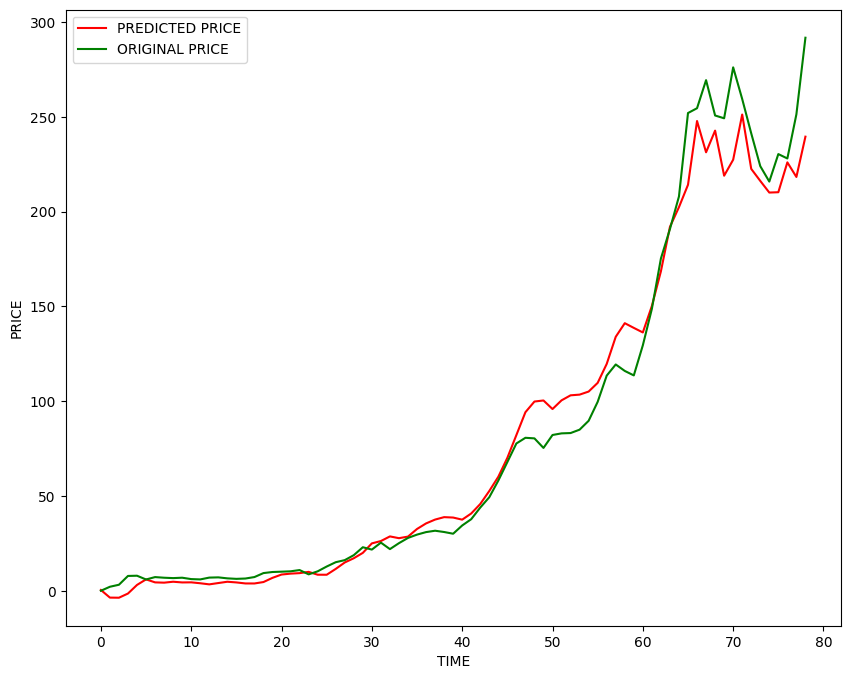

0.9750813489470297
14.271529849441826


In [36]:
plt.figure(figsize=(10,8))
plt.plot(y_predict,'r',label='PREDICTED PRICE')
plt.plot(y,'g',label='ORIGINAL PRICE')
plt.xlabel('TIME')
plt.ylabel('PRICE')
plt.legend()
plt.show()


from sklearn.metrics import r2_score as r2s
from sklearn.metrics import mean_squared_error as mse
r2 = r2s(y, y_predict)
mean_error = mse(y, y_predict)


print(r2)
print(np.sqrt(mean_error))

In [37]:
model.save('Stock extremes 2025.keras')